# Clustering of time series from HATCH

In [2]:
import matplotlib.pylab as plt
import numpy as np
import pandas as pd

savefig_settings = {'bbox_inches': 'tight', 'facecolor': 'w', 'dpi': 300}
save_fig = True

from read_hatch import read_hatch

## Import and display data

In [3]:
# read hatch data

dh = read_hatch('data/HATCH_v1.5_clean.csv')
dh = dh.loc[:, 1700:2025].dropna(axis=1, how='all')

Removed timeseries with constant values: 57


<Axes: >

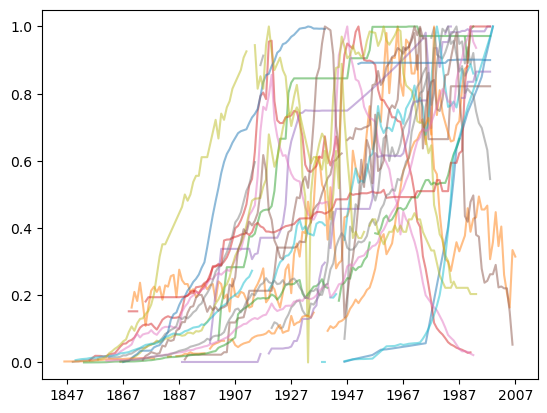

In [4]:
dh_norm = dh.divide(dh.max(axis=1), axis=0)
dh_norm.iloc[100:120].transpose().plot(legend=False, alpha=0.5)

In [5]:
# plotting with aligned x axis on first year on record

dh_norm_shifted = dh_norm.copy()

for i in dh_norm.index:
    n_leading_nans = (dh_norm.loc[i].notnull().cumsum() == 0).sum()
    dh_norm_shifted.loc[i] = dh_norm.loc[i].shift(-n_leading_nans)

dh_norm_shifted.columns = pd.RangeIndex(0, dh_norm.shape[1], name='years since first datapoint')

<Axes: xlabel='years since first datapoint'>

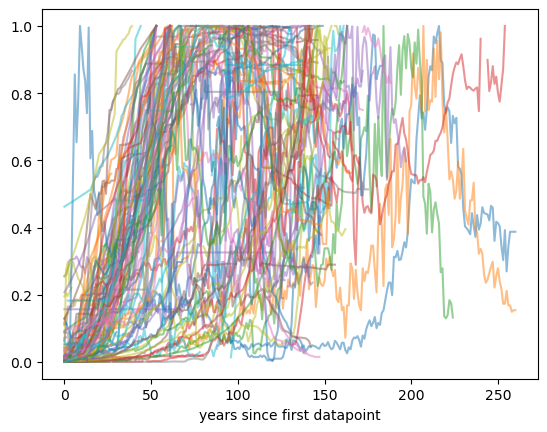

In [6]:
dh_norm_shifted.iloc[:100].transpose().plot(legend=False, alpha=0.5)

<Axes: >

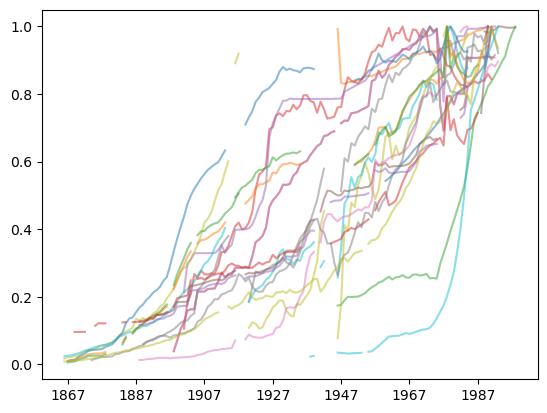

In [7]:
# apply rolling average to minimize fluctuations

rdh = dh.rolling(3).mean()

rdh_norm = rdh.divide(rdh.max(axis=1), axis=0)
rdh_norm.iloc[100:120].transpose().plot(legend=False, alpha=0.5)

## Clustering using specific time series clustering with method with time wharping

Materials:

https://towardsdatascience.com/time-series-clustering-deriving-trends-and-archetypes-from-sequential-data-bb87783312b4

https://tslearn.readthedocs.io/en/stable/index.html
->
https://tslearn.readthedocs.io/en/stable/user_guide/clustering.html

In [ ]:
import tslearn

from tslearn.clustering import TimeSeriesKMeans

seed = 16737
n_clusters = 5
model = TimeSeriesKMeans(n_clusters=n_clusters, metric="dtw",
                         max_iter=10, random_state=seed)
# filter training data:
# cut very long datasets
df_train = dh_norm_shifted.loc[:, 0:59]
# drop very short datasets
c = df_train[df_train.notna().sum(axis=1) >= 20]
print(len(df_train))
X_train = df_train.to_numpy()
model.fit(X_train)

4401


TimeSeriesKMeans(max_iter=10, metric='dtw', n_clusters=5, random_state=16737)

In [21]:
cluster_ids = model.predict(X_train)

/home/finn/miniconda3/envs/datenv/lib/python3.10/site-packages/tslearn/utils/utils.py:90: UserWarning: 2-Dimensional data passed. Assuming these are 4401 1-dimensional timeseries
  warnings.warn(


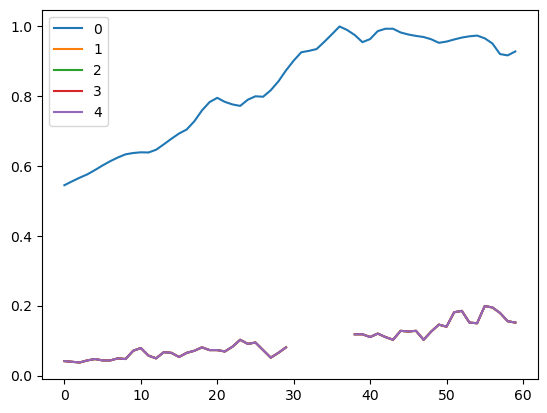

In [23]:
for id in range(n_clusters):
    plt.plot(df_train.columns.to_numpy(), model.cluster_centers_[id], label=id)

plt.legend()

In [24]:
unique, counts = np.unique(cluster_ids, return_counts=True)
counts

array([4401])

# Clustering based on goodness of fit results

In [8]:
# load fitting parameters and metadata

day = '2024-10-22'
sample =  'all' # 'randomsample500'

metadata = pd.read_csv("./data/combined_tech_characteristics.csv", index_col=0)
ts_stats = pd.read_csv(f"./results/timeseries_stats_{sample}_2024-10-21.csv", index_col=0)
params = pd.read_csv(f"./results/fitting_parameters_{sample}_{day}.csv", index_col=0)
print("number of time series:", len(ts_stats))
print("number of metadata:", len(metadata))
print("number of fit parameter sets:", len(params))

number of time series: 4272
number of metadata: 203
number of fit parameter sets: 38448


In [9]:
params = params.loc[params['fit_success']]
metadata['Technology Name'] = metadata.index

full_table = pd.merge(params, ts_stats.drop('Technology Name', axis=1), how = 'left', left_on = 'technology', right_on = 'tech_name')
print(len(full_table))
full_table = pd.merge(full_table, metadata, how = 'left', left_on = 'Technology Name', right_on='Technology Name')
print(len(full_table))
# there seem to be duplicate matches, which need to be removed
full_table = full_table.drop_duplicates(subset=params.columns)
print(len(full_table))

38394
44081
38394


In [ ]:
r2_vals = full_table.pivot(index='technology', columns='functional_form', values='r_squared')
r2_vals = r2_vals.where(r2_vals > 0, 0)
r2_vals = r2_vals.dropna()

from sklearn.cluster import KMeans

n_clusters = 7
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto").fit(r2_vals.to_numpy())

In [14]:
cluster_labels = pd.Series(data=kmeans.labels_, index=r2_vals.index)

In [15]:
cluster_labels

technology
Acrylic Fiber_Annual production_World         2
Acrylonitrile_Annual production_World         2
Air-Source Heat Pumps_Annual Production_US    0
All Biofuels_Annual Production_AR             2
All Biofuels_Annual Production_AT             2
                                             ..
Zinc_Annual Production_MX                     0
Zinc_Annual Production_PE                     2
Zinc_Annual Production_US                     2
Zinc_Annual Production_ZM                     2
Zinc_Annual production_World                  2
Length: 4272, dtype: int32

In [12]:
for cluster_id in range(n_clusters):
    #print(kmeans.cluster_centers_[cluster_id])
    ts_ids = cluster_labels[cluster_labels == cluster_id].index

    dh_norm.loc[ts_ids].transpose().plot(legend=False, alpha=0.5)
    center_str = ",".join(["{0:0.2f}".format(i) for i in kmeans.cluster_centers_[cluster_id]])
    plt.title("center: " + center_str + "; n=" + str(len(ts_ids)))
    #plt.savefig(f'figures/timeseries_cluster{cluster_id}.png')

AttributeError: 'numpy.ndarray' object has no attribute 'index'

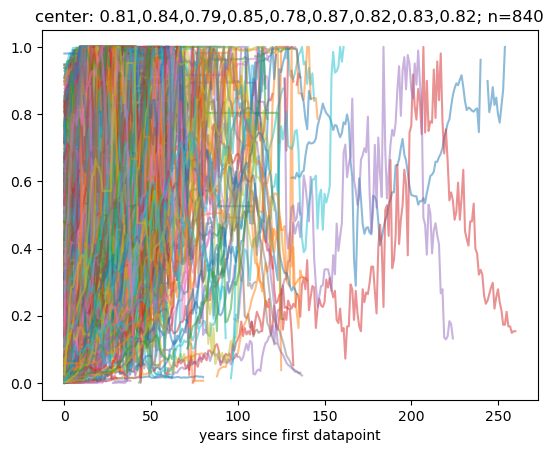

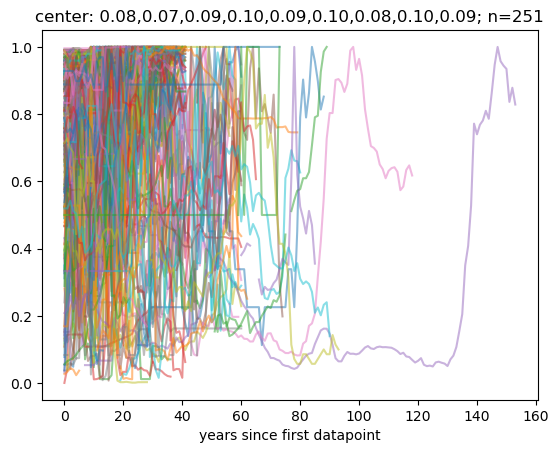

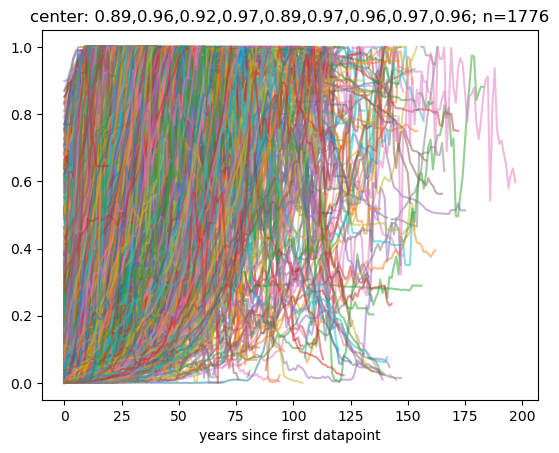

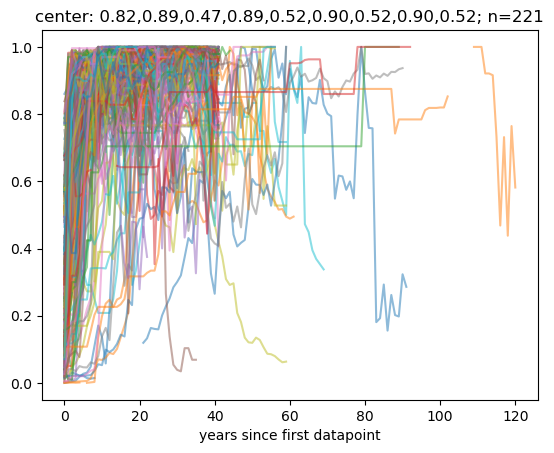

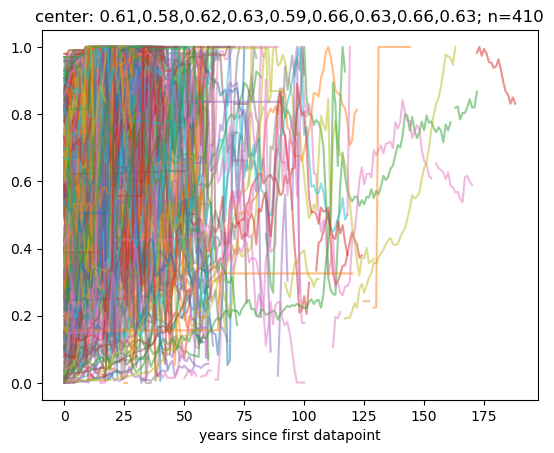

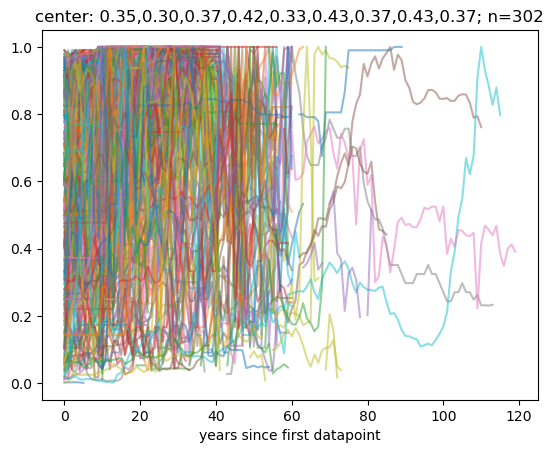

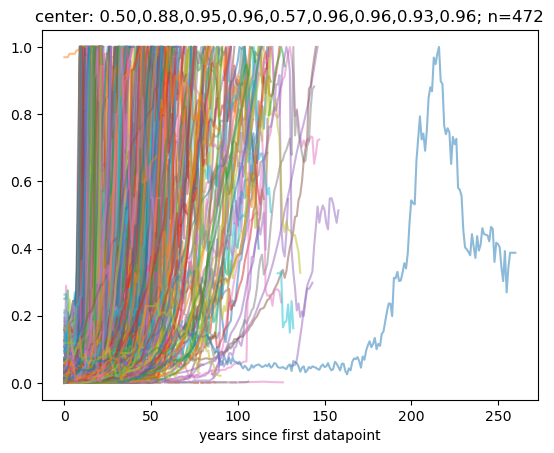

In [ ]:
# Adjust timing (e.g. from first datapoint) for better displaying
for cluster_id in range(n_clusters):
    ts_ids = cluster_labels[cluster_labels == cluster_id].index

    dh_norm_shifted.loc[ts_ids].transpose().plot(legend=False, alpha=0.5)
    center_str = ",".join(["{0:0.2f}".format(i) for i in kmeans.cluster_centers_[cluster_id]])
    plt.title("center: " + center_str + "; n=" + str(len(ts_ids)))
    plt.savefig(f'figures/timeseries_cluster{cluster_id}.png')

In [30]:
# plot means / medians
for cluster_id in range(n_clusters):
    ts_ids = cluster_labels[cluster_labels == cluster_id].index
    dh_norm_shifted.loc[ts_ids].mean().transpose().plot(legend=False, alpha=0.5, label=f"{cluster_id} (n={len(ts_ids)})")

plt.xlim([0, 70])
plt.legend()
plt.ylabel('cluster mean')

NameError: name 'cluster_labels' is not defined

<Axes: >

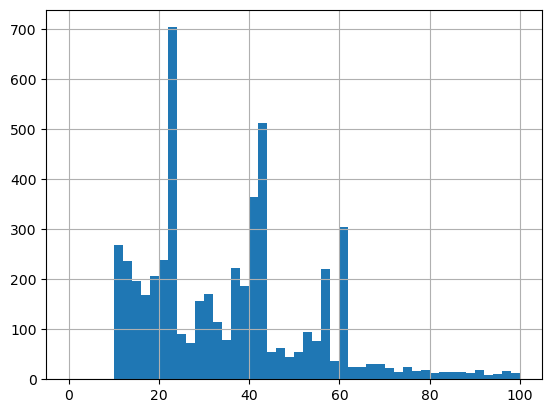

In [91]:
dh_norm_shifted.notna().sum(axis=1).hist(bins=50, range=[0, 100])

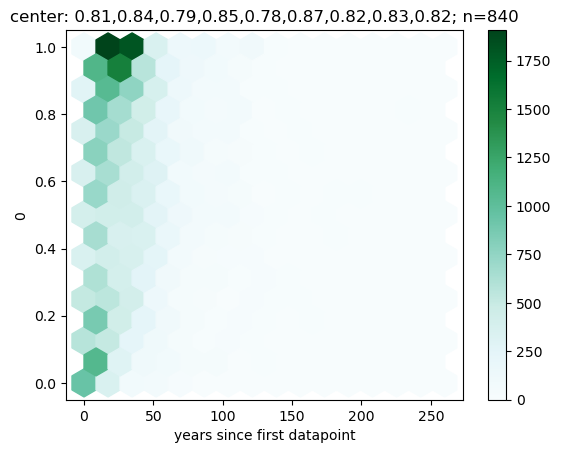

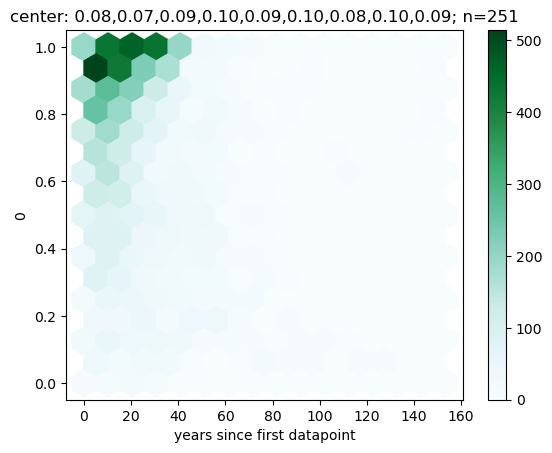

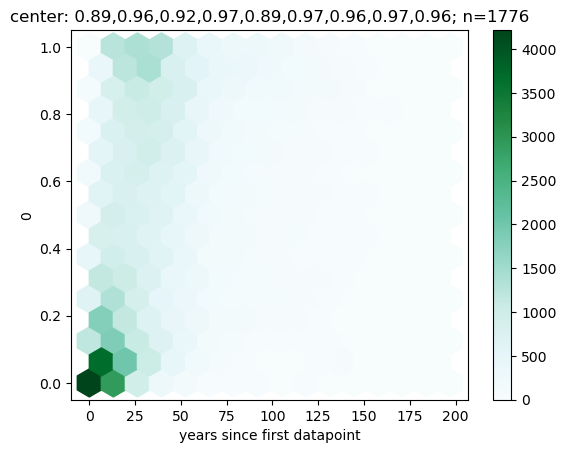

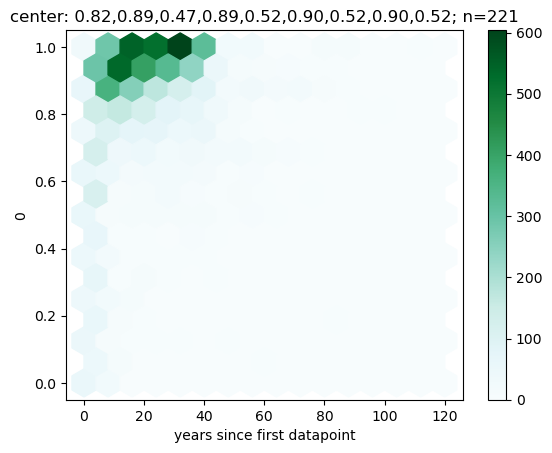

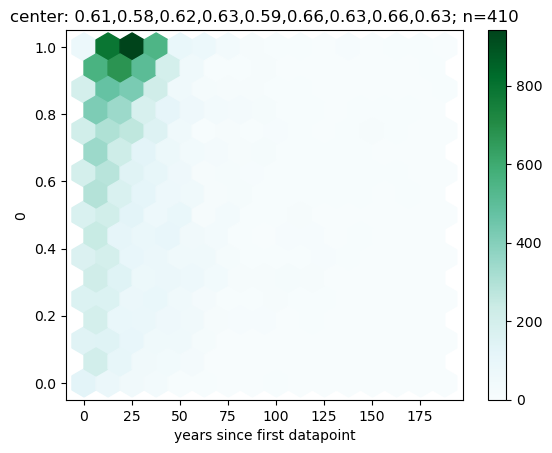

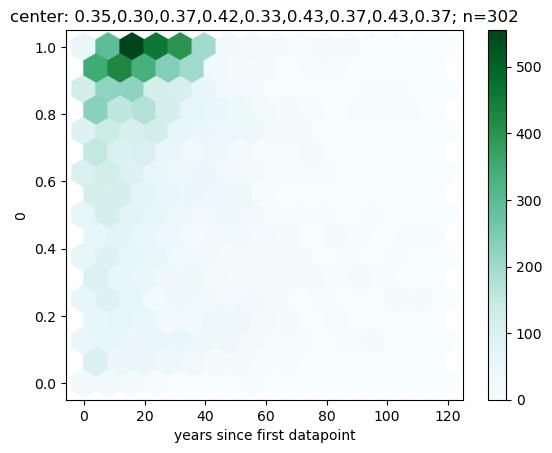

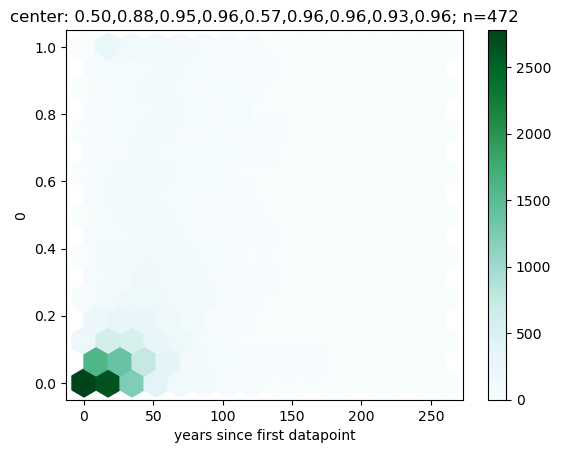

In [114]:
# plot density instead of line plots

for cluster_id in range(n_clusters):
    #print(kmeans.cluster_centers_[cluster_id])
    ts_ids = cluster_labels[cluster_labels == cluster_id].index

    dh_norm_shifted.loc[ts_ids].stack().reset_index().plot.hexbin(x='years since first datapoint', y=0, gridsize=15)
    center_str = ",".join(["{0:0.2f}".format(i) for i in kmeans.cluster_centers_[cluster_id]])
    plt.title("center: " + center_str + "; n=" + str(len(ts_ids)))

640


<Axes: xlabel='years since first datapoint'>

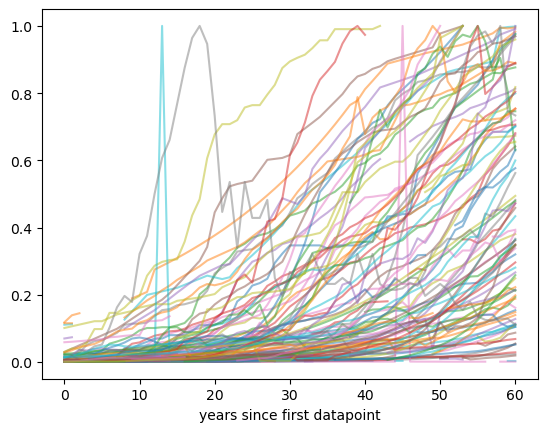

In [134]:
# plot subset of time series with very high r_squared
ts_ids = full_table[(full_table['r_squared'] > 0.99) & (full_table['functional_form'] == 'logistic')]['technology']
print(len(ts_ids))
dh_norm_shifted.loc[ts_ids].transpose().loc[0:60].iloc[:, 0:100].plot(legend=False, alpha=0.5)

## Todos:

- Fingerprints for filtering timeseries for raw data visualization (e.g. dy / mean_y, convexity at the end)

- Check effect of cutting data at maximum for distribution of R2!
- Apply other filters/preprocessing:
    - remove timeseries with only two distinct values
    - remove annual production time series or use their cumulative sums

Questions:
- How to deal with peak and decline?
